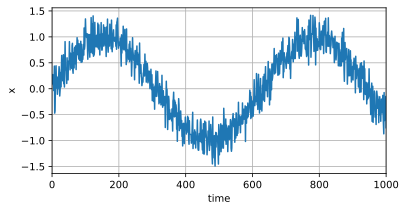

In [26]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T, ))
d2l.plot(time, [x], 'time', 'x', xlim=[0, 1000], figsize=(6, 3))

In [27]:
tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600

train_iter = d2l.load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

In [28]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(4, 10), nn.ReLU(), nn.Linear(10, 1))

    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')

In [29]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch: {epoch + 1}, loss: {d2l.evaluate_loss(net, train_iter, loss)} \n')

net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch: 1, loss: 0.059362019499142965 

epoch: 2, loss: 0.054608470449844994 

epoch: 3, loss: 0.05423401768008868 

epoch: 4, loss: 0.05402446866035462 

epoch: 5, loss: 0.05159760306278865 



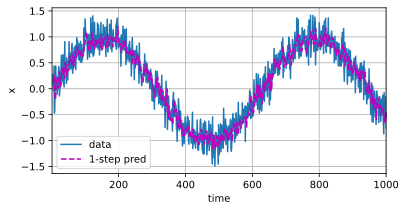

In [30]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]], [x.detach().numpy(), onestep_preds.detach().numpy()], 'time', 'x', 
         legend=['data', '1-step pred'], xlim=[1, 1000], figsize=(6, 3))

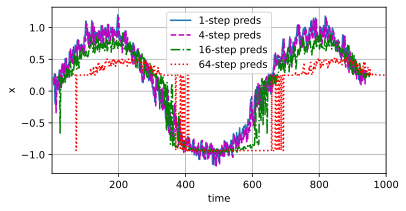

In [ ]:
max_step = 64

features = torch.zeros((T - tau - max_step + 1, tau + max_step))

for i in range(tau):
    features[:, i] = x[i: i + T - tau - max_step + 1]

for i in range(tau, tau + max_step):
    features[:, i] = net(features[:, i - tau: i]).reshape(-1)

steps = (1, 4, 16, 64)
d2l.plot(
    [time[tau + i - 1: T - max_step + i] for i in steps], 
    [features[:, (tau + i - 1)].detach().numpy() for i in steps], 
    'time', 
    'x', 
    legend=[f'{i}-step preds' for i in steps],
    xlim=[1, 1000], figsize=(6, 3)
)